In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
pd.to_numeric(df['TotalCharges'], errors='coerce')

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


<Axes: xlabel='Churn'>

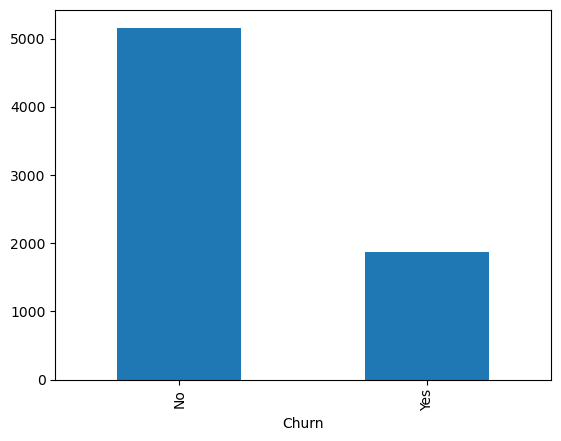

In [11]:
df['Churn'].value_counts().plot(kind='bar')

Text(0, 0.5, 'Count')

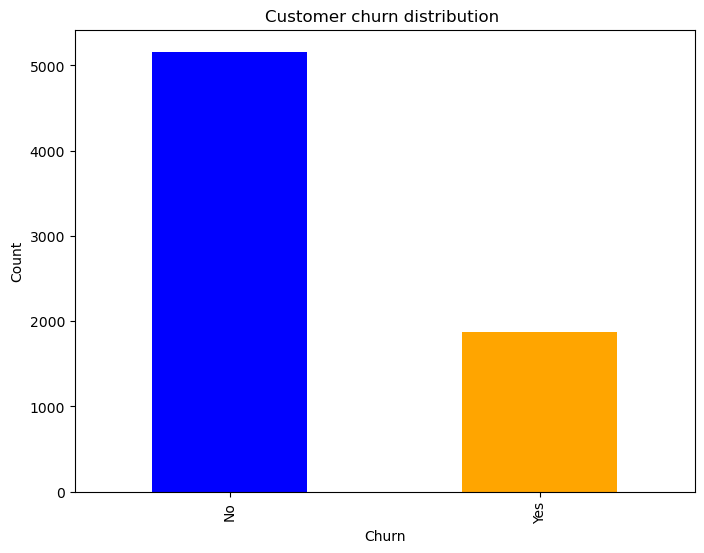

In [12]:
df['Churn'].value_counts().plot(kind='bar', figsize=(8, 6), color=['blue', 'orange'])
plt.title('Customer churn distribution ')
plt.xlabel('Churn')
plt.ylabel('Count')

In [13]:
df=pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,customerID_0015-UOCOJ,customerID_0016-QLJIS,customerID_0017-DINOC,customerID_0017-IUDMW,customerID_0018-NYROU,customerID_0019-EFAEP,customerID_0019-GFNTW,customerID_0020-INWCK,customerID_0020-JDNXP,customerID_0021-IKXGC,customerID_0022-TCJCI,customerID_0023-HGHWL,customerID_0023-UYUPN,customerID_0023-XUOPT,customerID_0027-KWYKW,customerID_0030-FNXPP,customerID_0031-PVLZI,customerID_0032-PGELS,customerID_0036-IHMOT,customerID_0040-HALCW,customerID_0042-JVWOJ,customerID_0042-RLHYP,customerID_0048-LUMLS,customerID_0048-PIHNL,customerID_0052-DCKON,customerID_0052-YNYOT,customerID_0056-EPFBG,customerID_0057-QBUQH,customerID_0058-EVZWM,...,customerID_9972-VAFJJ,customerID_9974-JFBHQ,customerID_9975-GPKZU,customerID_9975-SKRNR,customerID_9978-HYCIN,customerID_9979-RGMZT,customerID_9985-MWVIX,customerID_9986-BONCE,customerID_9987-LUTYD,customerID_9992-RRAMN,customerID_9992-UJOEL,customerID_9993-LHIEB,customerID_9995-HOTOH,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,Fals

In [14]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#df[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df[['tenure', 'MonthlyCharges', 'TotalCharges']])

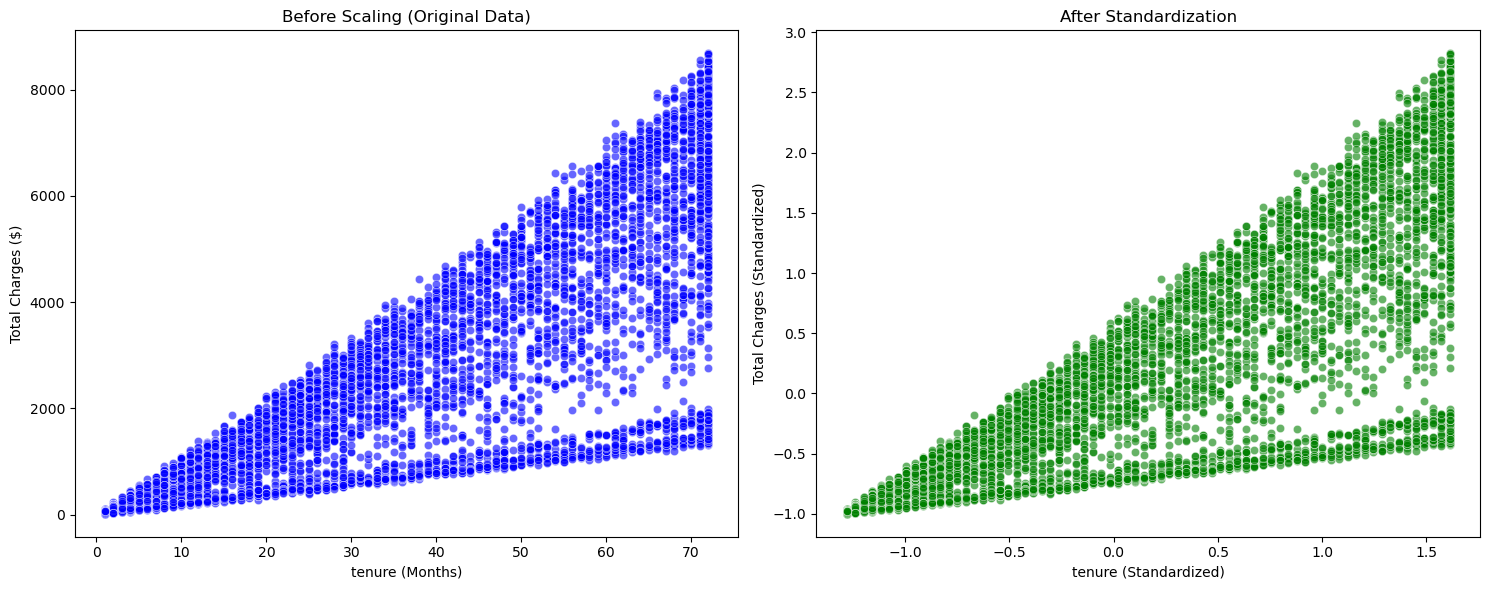

In [15]:
from sklearn.preprocessing import StandardScaler
df_scaled = df.copy()
scaler = StandardScaler()
df_scaled[['tenure','MonthlyCharges','TotalCharges']] = scaler.fit_transform(df[['tenure', 'MonthlyCharges', 'TotalCharges']])
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', ax=axes[0], alpha=0.6, color='blue')
axes[0].set_title('Before Scaling (Original Data)')
axes[0].set_xlabel('tenure (Months)')
axes[0].set_ylabel('Total Charges ($)')
sns.scatterplot(data=df_scaled, x='tenure', y='TotalCharges', ax=axes[1], alpha=0.6, color='green')
axes[1].set_title('After Standardization')
axes[1].set_xlabel('tenure (Standardized)')
axes[1].set_ylabel('Total Charges (Standardized)')
plt.tight_layout()
plt.show()

In [16]:
X = df.drop('Churn_Yes', axis=1)  # Features (all columns except target)
y = df['Churn_Yes']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0] / len(df) * 100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0] / len(df) * 100:.1f}%)")

Training set size: 5625 (80.0%)
Test set size: 1407 (20.0%)


In [17]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

c:\Users\hppat\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [18]:
from sklearn.neighbors import KNeighborsClassifier
#we st K=5 means it will look ar the 5 closest neighbours
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [19]:
from sklearn.ensemble import RandomForestClassifier

#We initialize a forest with 100 trees (n_esimators)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
from sklearn.metrics import classification_report

# Assuming you already made predictions, e.g., log_preds = log_model.predict(X_test)
print("--- Logistic Regression Report ---")
log_preds = log_model.predict(X_test)
print("--- Logistic Regression Report ---")
print(classification_report(y_test, log_preds))

--- Logistic Regression Report ---
--- Logistic Regression Report ---
              precision    recall  f1-score   support

       False       0.83      0.88      0.86      1033
        True       0.61      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [22]:
print("--- KNN Report ---")
knn_model_preds = knn_model.predict(X_test)
print(classification_report(y_test, knn_model_preds))

--- KNN Report ---
              precision    recall  f1-score   support

       False       0.82      0.89      0.85      1033
        True       0.59      0.45      0.51       374

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.76      0.77      0.76      1407



In [23]:
print("--- Random Forest Report ---")
rf_model_preds = rf_model.predict(X_test)   
print(classification_report(y_test, rf_model_preds))    

--- Random Forest Report ---
              precision    recall  f1-score   support

       False       0.82      0.92      0.86      1033
        True       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



In [25]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [26]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("After SMOTE:")
print(y_train_smote.value_counts())



Before SMOTE:
Churn_Yes
False    4130
True     1495
Name: count, dtype: int64
After SMOTE:
Churn_Yes
True     4130
False    4130
Name: count, dtype: int64


In [30]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1500)
log_model.fit(X_train_smote, y_train_smote)
log_preds = log_model.predict(X_test)
print("--- Logistic Regression Report ---")
print(classification_report(y_test, log_preds))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

       False       0.85      0.85      0.85      1033
        True       0.59      0.59      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



c:\Users\hppat\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\hppat\AppData\Local\Temp\ipykernel_18992\956483625.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')


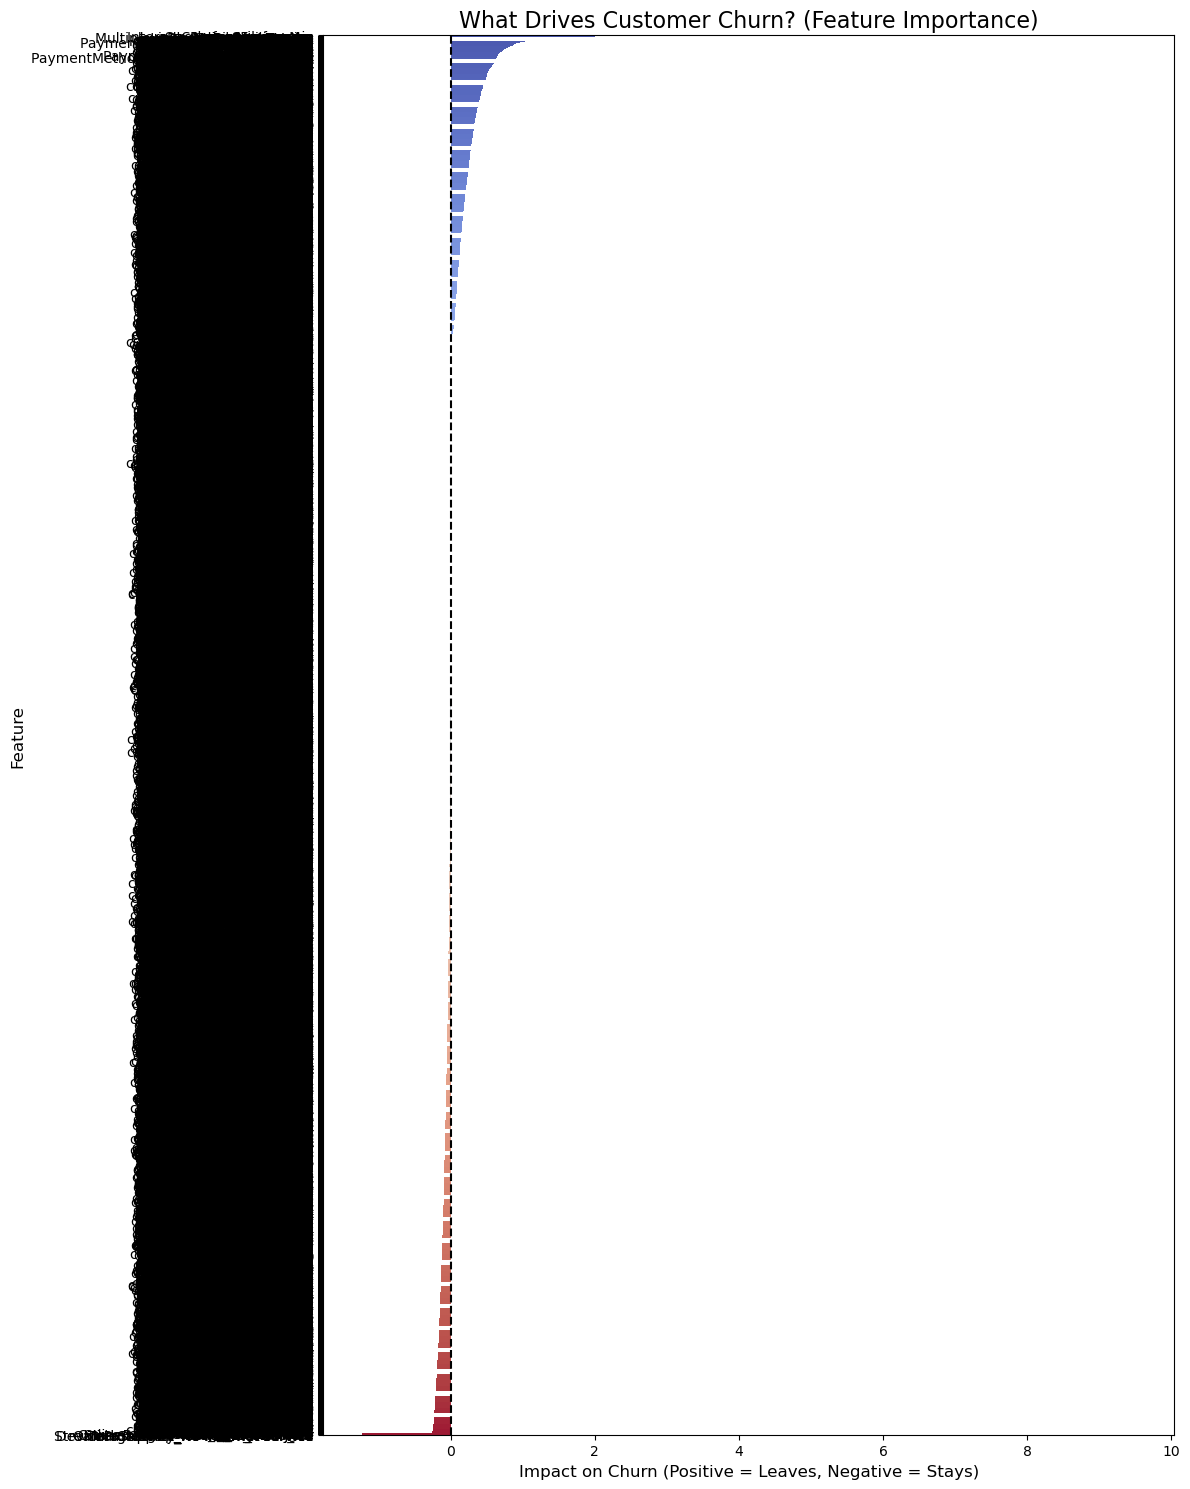

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

weights = log_model.coef_[0]
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': weights})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 15))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')
plt.title('What Drives Customer Churn? (Feature Importance)', fontsize=16)
plt.xlabel('Impact on Churn (Positive = Leaves, Negative = Stays)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.yticks(fontsize=10)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\hppat\AppData\Local\Temp\ipykernel_18992\1343969967.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette=['red' if x > 0 else 'green' for x in top_features['Importance']])


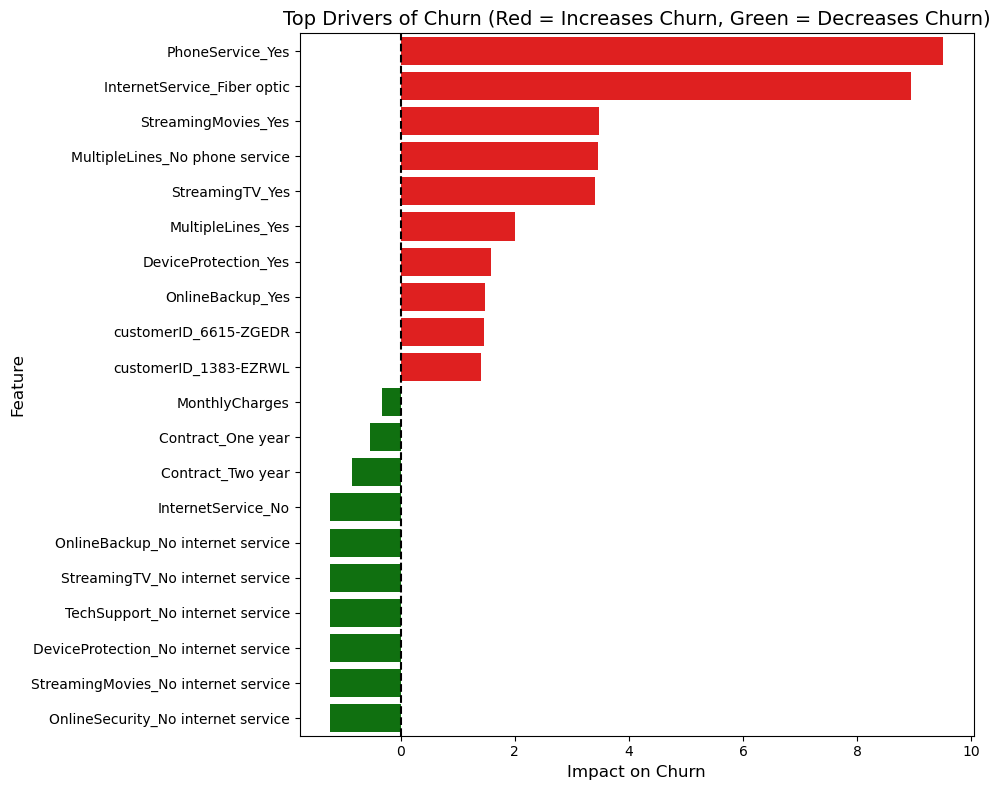

In [33]:
top_churners = feature_importance.head(10)
top_loyal = feature_importance.tail(10)
top_features = pd.concat([top_churners, top_loyal])

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette=['red' if x > 0 else 'green' for x in top_features['Importance']])
plt.title('Top Drivers of Churn (Red = Increases Churn, Green = Decreases Churn)', fontsize=14)
plt.xlabel('Impact on Churn', fontsize=12)  
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

**Building Fake customer**


In [35]:
import pandas as pd
import numpy as np

# 1. Create a "blank" customer with the exact same columns as your training data
fake_customer = pd.DataFrame(np.zeros((1, len(X_train.columns))), columns=X_train.columns)

# 2. Let's customize them based on our insights!
# Give them Phone Service (The biggest driver of churn)
if 'PhoneService_Yes' in fake_customer.columns:
    fake_customer['PhoneService_Yes'] = 1

# Make sure they DO NOT have Online Security (The biggest driver of loyalty)
if 'OnlineSecurity_Yes' in fake_customer.columns:
    fake_customer['OnlineSecurity_Yes'] = 0

# Let's give them a short tenure and high charges 
# (Since your data is scaled from 0 to 1, 0.1 is roughly a few months, and 0.8 is a high bill)
if 'tenure' in fake_customer.columns:
    fake_customer['tenure'] = 0.1
if 'TotalCharges' in fake_customer.columns:
    fake_customer['TotalCharges'] = 0.8

# 3. Make the Prediction!
# .predict() gives a hard 1 or 0
prediction = log_model.predict(fake_customer)

# .predict_proba() gives the actual percentage probability!
probability = log_model.predict_proba(fake_customer)

# 4. Print the results like a pro
print("--- Hypothetical Customer Prediction ---")
if prediction[0] == 1:
    print("AI Decision: 🔴 AT RISK OF CHURNING (Will Leave)")
else:
    print("AI Decision: 🟢 SAFE (Will Stay)")
    
# probability[0][1] grabs the percentage chance of the '1' (Churn) class
print(f"Churn Probability: {probability[0][1] * 100:.2f}%")

--- Hypothetical Customer Prediction ---
AI Decision: 🔴 AT RISK OF CHURNING (Will Leave)
Churn Probability: 100.00%
